## 03 – Isochronen mit OpenRouteService (ORS)

Fahrzeit-Isochronen fuer Apotheken in der Schweiz.
- Eingabe: `data/processed/pharmacies_ch.geojson` (EPSG:2056)
- Public ORS API (Key in `../.env`)
- ORS erwartet WGS84 (EPSG:4326) → wir transformieren LV95→WGS84→LV95

In [6]:
# 1) Imports + API Setup
from __future__ import annotations
import json, os, time
from pathlib import Path
from typing import Any, Dict, Optional
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

PROCESSED = Path('..') / 'data' / 'processed'
OUTPUTS   = Path('..') / 'outputs' / 'maps'
OUTPUTS.mkdir(parents=True, exist_ok=True)

ORS_BASE_URL = 'https://api.openrouteservice.org'

# Key laden: zuerst Env-Var, dann .env Datei
def _load_env_key(path: Path, key: str) -> str:
    if not path.exists():
        return ''
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip().lstrip('\ufeff')
        if line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        if k.strip() == key:
            return v.strip().strip('"').strip("'")
    return ''

DOTENV = (Path('..') / '.env').resolve()
ORS_API_KEY = os.getenv('ORS_API_KEY', '').strip() or _load_env_key(DOTENV, 'ORS_API_KEY')

print('Setup OK')
print('- PROCESSED:', PROCESSED.resolve())
print('- OUTPUTS:  ', OUTPUTS.resolve())
print('- .env:     ', DOTENV, '| exists:', DOTENV.exists())
print('- API Key gesetzt:', bool(ORS_API_KEY), '| Laenge:', len(ORS_API_KEY))

def _endpoint(profile: str) -> str:
    return f"{ORS_BASE_URL.rstrip('/')}/v2/isochrones/{profile}"

def ors_isochrones(profile: str, lon: float, lat: float, ranges_s: list,
                   timeout_s: int = 30, retry: int = 2, sleep_s: float = 3.0) -> dict:
    if not ORS_API_KEY:
        raise RuntimeError('ORS_API_KEY fehlt!')
    payload = {'locations': [[lon, lat]], 'range': ranges_s, 'range_type': 'time'}
    headers = {'Content-Type': 'application/json', 'Authorization': ORS_API_KEY}
    url = _endpoint(profile)
    last_err = None
    for attempt in range(retry + 1):
        try:
            r = requests.post(url, headers=headers, data=json.dumps(payload), timeout=timeout_s)
            if r.status_code >= 400:
                raise RuntimeError(f'ORS {r.status_code}: {r.text[:200]}')
            time.sleep(sleep_s)
            return r.json()
        except Exception as e:
            last_err = e
            wait = 5.0 + attempt * 10
            print(f'  Versuch {attempt+1}/{retry+1} fehlgeschlagen: {e}. Warte {wait}s...')
            time.sleep(wait)
    raise RuntimeError(f'ORS gescheitert: {last_err}')

Setup OK
- PROCESSED: C:\Projects\pharmacy-accessibility-ch\data\processed
- OUTPUTS:   C:\Projects\pharmacy-accessibility-ch\outputs\maps
- .env:      C:\Projects\pharmacy-accessibility-ch\.env | exists: True
- API Key gesetzt: True | Laenge: 120


Apotheken: 1640
Testpunkt WGS84: (8.7262, 47.2410)
Abfrage foot-walking...
OK – Features (walk): 3
Abfrage driving-car...
OK – Features (car): 3
Flaeche Auto (km2): [8.76, 33.92, 81.77]


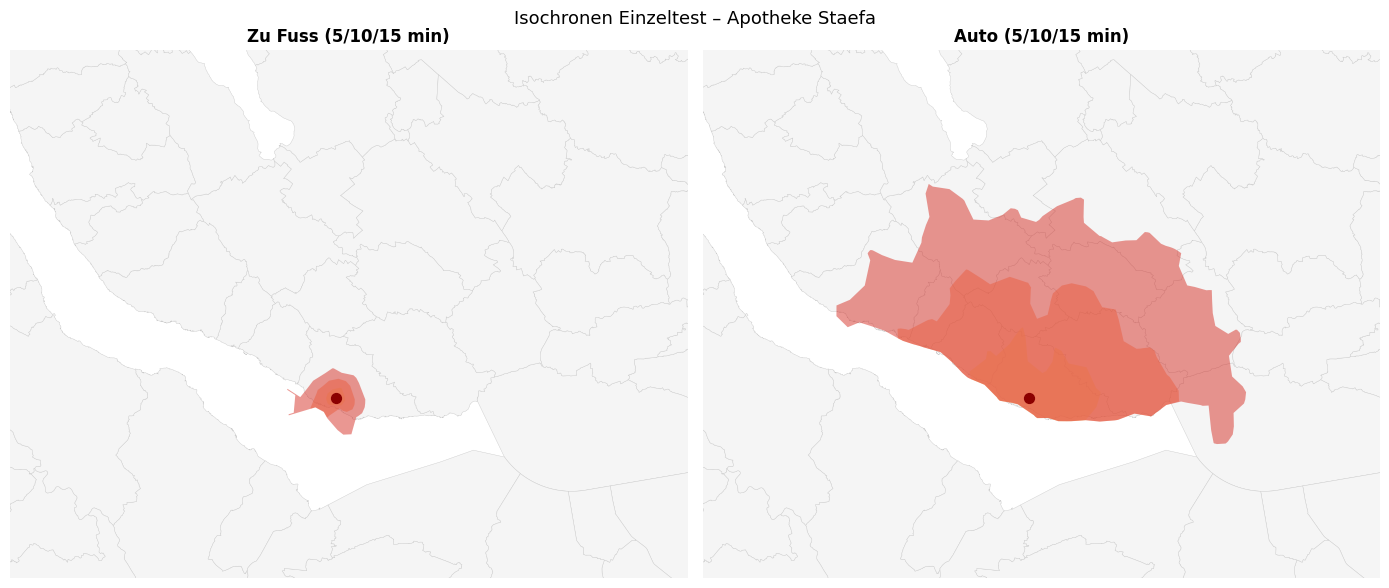

Karte gespeichert: ..\outputs\maps\03_einzeltest_isochrone.png


In [7]:
# 2) Einzeltest: Eine Apotheke, Fuss + Auto
gdf_pharm = gpd.read_file(PROCESSED / 'pharmacies_ch.geojson').to_crs(2056)
gdf_gem   = gpd.read_file(PROCESSED / 'gemeinden_ch.geojson').to_crs(2056)
print('Apotheken:', len(gdf_pharm))

row0 = gdf_pharm.iloc[0]
pt_wgs84 = gpd.GeoSeries([row0.geometry], crs=2056).to_crs(4326).iloc[0]
lon0, lat0 = float(pt_wgs84.x), float(pt_wgs84.y)
ranges_s = [5*60, 10*60, 15*60]

print(f'Testpunkt WGS84: ({lon0:.4f}, {lat0:.4f})')
print('Abfrage foot-walking...')
res_walk = ors_isochrones('foot-walking', lon0, lat0, ranges_s)
print('OK – Features (walk):', len(res_walk.get('features', [])))

print('Abfrage driving-car...')
res_car = ors_isochrones('driving-car', lon0, lat0, ranges_s)
print('OK – Features (car):', len(res_car.get('features', [])))

gdf_walk = gpd.GeoDataFrame.from_features(res_walk['features'], crs=4326).to_crs(2056)
gdf_car  = gpd.GeoDataFrame.from_features(res_car['features'],  crs=4326).to_crs(2056)
print('Flaeche Auto (km2):', (gdf_car.area / 1e6).round(2).tolist())

# Visualisierung Einzeltest
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#fee08b', '#fc8d59', '#d73027']
titles = ['Zu Fuss (5/10/15 min)', 'Auto (5/10/15 min)']
for ax, gdf_iso, title in zip(axes, [gdf_walk, gdf_car], titles):
    gdf_gem.plot(ax=ax, color='#f5f5f5', edgecolor='#cccccc', linewidth=0.3)
    for idx, (_, row) in enumerate(gdf_iso.iterrows()):
        gpd.GeoDataFrame([row], crs=2056).plot(ax=ax, color=colors[idx % 3], alpha=0.5)
    gpd.GeoDataFrame([gdf_pharm.iloc[0]], geometry='geometry', crs=2056).plot(
        ax=ax, color='darkred', markersize=50, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_axis_off()
    xmin, ymin, xmax, ymax = gdf_car.total_bounds
    pad = 5000
    ax.set_xlim(xmin-pad, xmax+pad)
    ax.set_ylim(ymin-pad, ymax+pad)
plt.suptitle('Isochronen Einzeltest – Apotheke Staefa', fontsize=13)
plt.tight_layout()
out = OUTPUTS / '03_einzeltest_isochrone.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Karte gespeichert:', out)

In [8]:
# 3) Stichprobe: 20 Apotheken, 5min Auto
# Rate Limit: 20 req/min -> 3s Pause zwischen Calls
SAMPLE_SIZE = 20
gdf_sample = gdf_pharm.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'Stichprobe: {SAMPLE_SIZE} von {len(gdf_pharm)} Apotheken')

results = []
ranges_5min = [5 * 60]

for i, row in gdf_sample.iterrows():
    pt_wgs84 = gpd.GeoSeries([row.geometry], crs=2056).to_crs(4326).iloc[0]
    lon, lat = float(pt_wgs84.x), float(pt_wgs84.y)
    try:
        res = ors_isochrones('driving-car', lon, lat, ranges_5min, sleep_s=3.0)
        for feat in res.get('features', []):
            feat['properties']['pharmacy_id'] = str(row.get('osm_id', i))
            feat['properties']['name'] = str(row.get('name', ''))
            results.append(feat)
        print(f'  {i+1}/{SAMPLE_SIZE} OK – {row.get("name", "?")}')
    except Exception as e:
        print(f'  {i+1}/{SAMPLE_SIZE} Fehler: {e}')

gdf_iso_sample = gpd.GeoDataFrame.from_features(results, crs=4326).to_crs(2056)
print(f'Isochronen berechnet: {len(gdf_iso_sample)}')
gdf_iso_sample.to_file(PROCESSED / 'isochrones_5min_car_sample.geojson', driver='GeoJSON')
print('Gespeichert: isochrones_5min_car_sample.geojson')

Stichprobe: 20 von 1640 Apotheken
  1/20 OK – Droguerie de Valère
  2/20 OK – Sonnen-Apotheke
  3/20 OK – Dropa Rosenberg
  4/20 OK – Floréal
  5/20 OK – Pharmacieplus des Forges
  6/20 OK – Amavita Glattzentrum
  Versuch 1/3 fehlgeschlagen: ORS 429: {
    "error": "Rate Limit Exceeded"
}. Warte 5.0s...
  7/20 OK – Sun Store
  8/20 OK – TopPharm Damian Apotheke & Drogerie
  9/20 OK – Puls Apotheke & Drogerie
  10/20 OK – Victoria Apotheke
  11/20 OK – Mistel-Apotheke
  12/20 OK – Apotheke & Drogerie, Riburg
  Versuch 1/3 fehlgeschlagen: ORS 429: {
    "error": "Rate Limit Exceeded"
}. Warte 5.0s...
  13/20 OK – Pharmacie du Lac
  14/20 OK – Frey AG
  Versuch 1/3 fehlgeschlagen: ORS 429: {
    "error": "Rate Limit Exceeded"
}. Warte 5.0s...
  15/20 OK – Sun Store
  16/20 OK – Apotheke Seuzach
  17/20 OK – Amavita
  18/20 OK – Dropa Hirsch Apotheke
  19/20 OK – Drogerie A. Jost
  20/20 OK – Drogama Apotheke Drogerie
Isochronen berechnet: 20
Gespeichert: isochrones_5min_car_sample.geojson

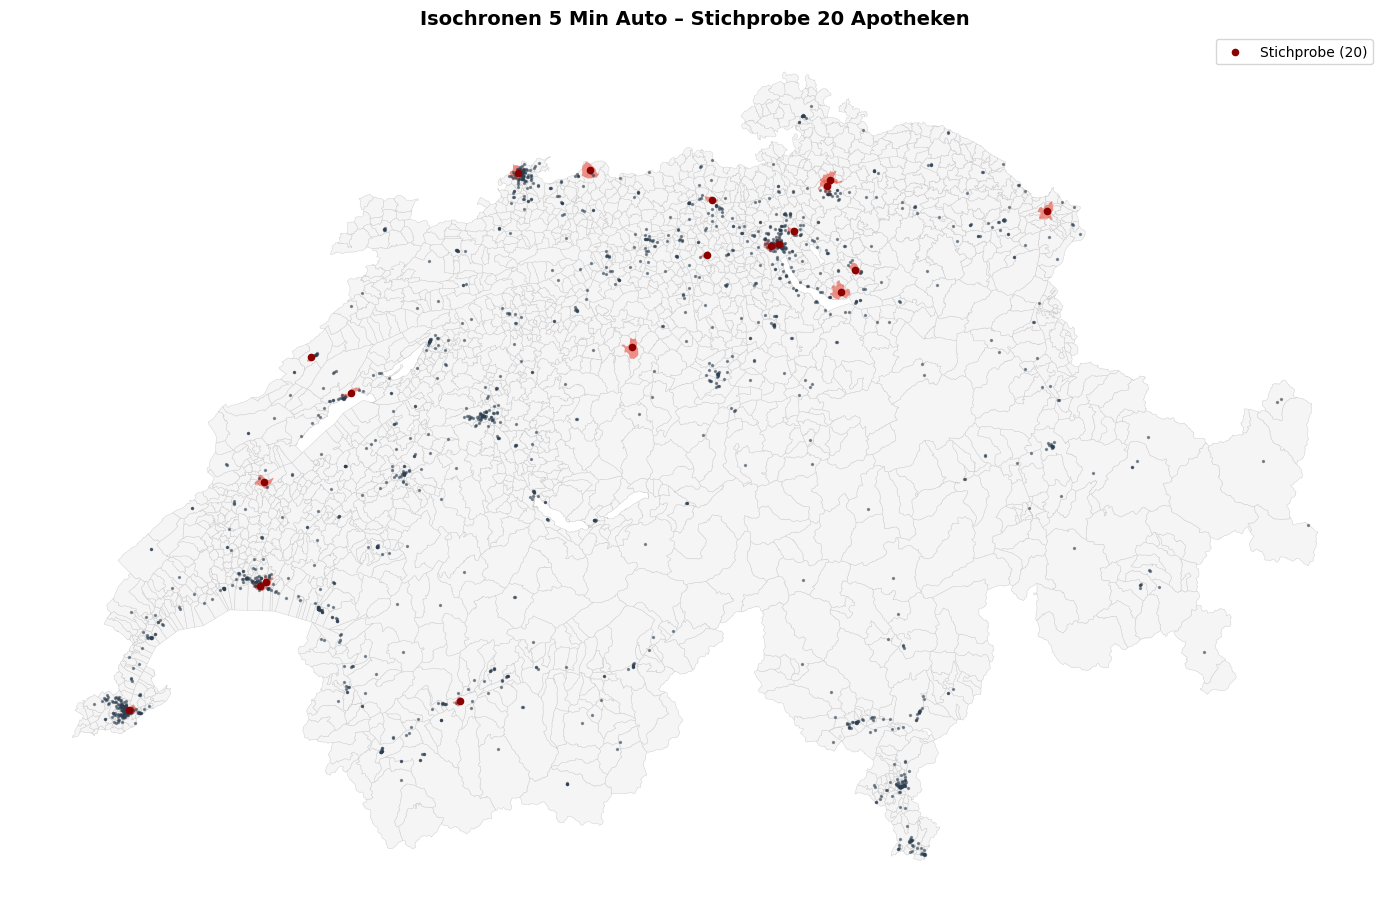

Karte gespeichert: ..\outputs\maps\03_isochronen_5min_auto.png


In [9]:
# 4) Karte: Isochronen ueber Gemeindegrenzen
fig, ax = plt.subplots(figsize=(14, 10))
gdf_gem.plot(ax=ax, color='#f5f5f5', edgecolor='#cccccc', linewidth=0.3)
gdf_iso_sample.plot(ax=ax, color='#e74c3c', alpha=0.6, edgecolor='none')
gdf_pharm.plot(ax=ax, color='#2c3e50', markersize=2, alpha=0.5)
gdf_sample.plot(ax=ax, color='darkred', markersize=20, zorder=5, label='Stichprobe (20)')
ax.set_title('Isochronen 5 Min Auto – Stichprobe 20 Apotheken', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(fontsize=10)
plt.tight_layout()
out = OUTPUTS / '03_isochronen_5min_auto.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Karte gespeichert:', out)

In [10]:
# 5) Ergebnisse speichern
print('Gespeicherte Outputs:')
for p in [PROCESSED / 'isochrones_5min_car_sample.geojson',
          OUTPUTS / '03_einzeltest_isochrone.png',
          OUTPUTS / '03_isochronen_5min_auto.png']:
    exists = p.exists()
    size = f'{p.stat().st_size/1024:.0f} KB' if exists else 'FEHLT'
    print(f'  {"OK" if exists else "XX"}  {p.name:<45} {size}')
print()

Gespeicherte Outputs:
  OK  isochrones_5min_car_sample.geojson            56 KB
  OK  03_einzeltest_isochrone.png                   216 KB
  OK  03_isochronen_5min_auto.png                   630 KB

